In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from pathlib import Path


np.random.seed(42)

EUROSAT_ROOT = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT'
UCMERCED_ROOT = '/kaggle/input/datasets/abdulhasibuddin/uc-merced-land-use-dataset/UCMerced_LandUse/Images'

eurosat_root = Path(EUROSAT_ROOT)
classes = sorted([d.name for d in eurosat_root.iterdir() if d.is_dir()])

records = []
for c in classes:
    for f in (eurosat_root / c).glob('*.jpg'):
        records.append({'path': str(f), 'class': c})
df = pd.DataFrame(records)

df['file_idx'] = df['path'].apply(lambda p: int(Path(p).stem.split('_')[-1]))
df['block_id'] = df['file_idx'] // 9
blocks = df['block_id'].unique()
np.random.shuffle(blocks)
n = len(blocks)
train_blocks = blocks[:int(0.7*n)]
val_blocks = blocks[int(0.7*n):int(0.85*n)]
df['split_block'] = df['block_id'].apply(lambda b: 'train' if b in train_blocks else ('val' if b in val_blocks else 'test'))

class EuroSATDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['class'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[row['class']]
        return img, label

# ImageNet normalization -- required since we're using ImageNet pretrained weights
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
eval_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_df = df[df['split_block'] == 'train']
val_df   = df[df['split_block'] == 'val']

train_ds = EuroSATDataset(train_df, transform=train_tf)
val_ds   = EuroSATDataset(val_df, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device, len(train_ds), len(val_ds))

cuda 18694 4175


In [2]:
model = models.resnet18(weights='IMAGENET1K_V1')

# freeze everything first -- Phase 1 only trains the new head
for param in model.parameters():
    param.requires_grad = False

# swap the final layer -- original resnet18 has a 1000-class head (ImageNet), we need 10
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

# sanity check -- confirm only the new head has trainable params right now
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"trainable params: {trainable} / {total}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


trainable params: 5130 / 11181642


In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)  # only optimizing the head -- matches what's actually trainable

phase1_train_losses = []
phase1_val_losses = []
phase1_val_accs = []

for epoch in range(3):
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)
    phase1_train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
    val_loss = val_loss / len(val_ds)
    val_acc = correct / len(val_ds)
    phase1_val_losses.append(val_loss)
    phase1_val_accs.append(val_acc)

    print(f"[Phase 1] epoch {epoch+1}/3 - train_loss {train_loss:.4f} - val_loss {val_loss:.4f} - val_acc {val_acc:.4f}")

[Phase 1] epoch 1/3 - train_loss 0.8645 - val_loss 0.5298 - val_acc 0.8369
[Phase 1] epoch 2/3 - train_loss 0.5327 - val_loss 0.4790 - val_acc 0.8510
[Phase 1] epoch 3/3 - train_loss 0.4851 - val_loss 0.4704 - val_acc 0.8498


In [4]:
# resnet18's layers are named layer1, layer2, layer3, layer4 (each is a "conv block")
# the brief wants the LAST 2 blocks unfrozen -- that's layer3 and layer4
for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name:
        param.requires_grad = True

# sanity check -- trainable count should jump up now
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"trainable params: {trainable} / {total}")

# new optimizer -- LR dropped 10x from 1e-3 to 1e-4, and now covers layer3+layer4+fc
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4
)

phase2_train_losses = []
phase2_val_losses = []
phase2_val_accs = []

for epoch in range(5):
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)
    phase2_train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
    val_loss = val_loss / len(val_ds)
    val_acc = correct / len(val_ds)
    phase2_val_losses.append(val_loss)
    phase2_val_accs.append(val_acc)

    print(f"[Phase 2] epoch {epoch+1}/5 - train_loss {train_loss:.4f} - val_loss {val_loss:.4f} - val_acc {val_acc:.4f}")

trainable params: 10498570 / 11181642
[Phase 2] epoch 1/5 - train_loss 0.2661 - val_loss 0.1714 - val_acc 0.9459
[Phase 2] epoch 2/5 - train_loss 0.1271 - val_loss 0.1565 - val_acc 0.9459
[Phase 2] epoch 3/5 - train_loss 0.0761 - val_loss 0.1454 - val_acc 0.9545
[Phase 2] epoch 4/5 - train_loss 0.0638 - val_loss 0.1526 - val_acc 0.9528
[Phase 2] epoch 5/5 - train_loss 0.0532 - val_loss 0.1426 - val_acc 0.9576


In [5]:
import pandas as pd

comparison = pd.DataFrame({
    'Phase': ['Phase 1 (frozen backbone)', 'Phase 2 (unfrozen last 2 blocks)'],
    'Final Train Loss': [phase1_train_losses[-1], phase2_train_losses[-1]],
    'Final Val Loss': [phase1_val_losses[-1], phase2_val_losses[-1]],
    'Final Val Accuracy': [phase1_val_accs[-1], phase2_val_accs[-1]],
    'Trainable Params': [5130, 10498570],
})
comparison

,Phase,Final Train Loss,Final Val Loss,Final Val Accuracy,Trainable Params
0,Phase 1 (frozen backbone),0.485123,0.470406,0.849820,5130
1,Phase 2 (unfrozen last 2 blocks),0.053178,0.142569,0.957605,10498570


                      precision    recall  f1-score   support

          AnnualCrop      0.932     0.973     0.952       449
              Forest      0.993     0.969     0.981       449
HerbaceousVegetation      0.914     0.964     0.938       449
             Highway      0.946     0.913     0.929       404
          Industrial      0.964     0.980     0.972       404
             Pasture      0.961     0.946     0.953       314
       PermanentCrop      0.941     0.913     0.927       404
         Residential      0.993     0.980     0.987       449
               River      0.950     0.933     0.941       404
             SeaLake      0.985     0.991     0.988       449

            accuracy                          0.958      4175
           macro avg      0.958     0.956     0.957      4175
        weighted avg      0.958     0.958     0.958      4175



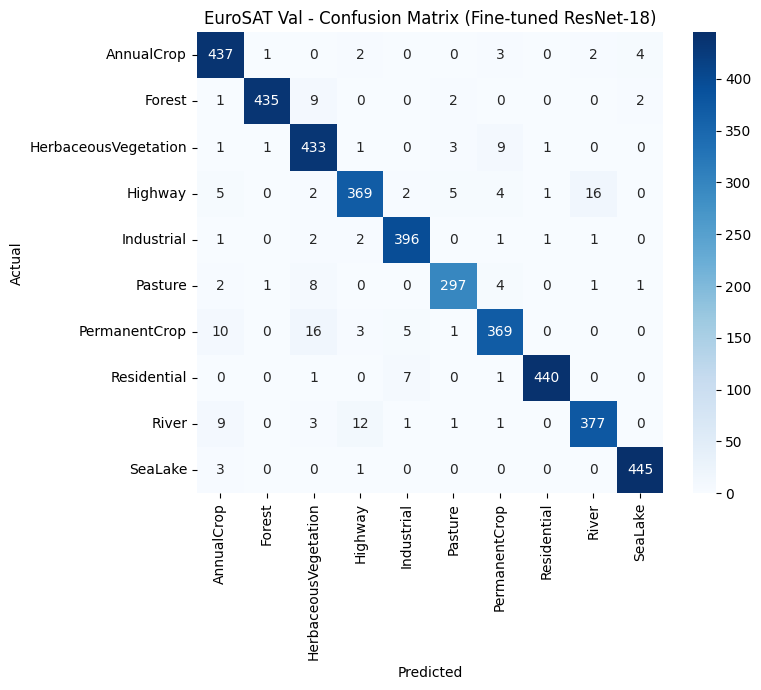

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes, digits=3))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EuroSAT Val - Confusion Matrix (Fine-tuned ResNet-18)')
plt.tight_layout()
plt.savefig('/kaggle/working/eurosat_confusion_matrix.png')
plt.show()

In [7]:
uc_root = Path(UCMERCED_ROOT)

# only classes with a genuine conceptual match to one of our 10 eurosat classes
ucmerced_to_eurosat = {
    'agricultural': 'AnnualCrop',
    'forest': 'Forest',
    'river': 'River',
    'freeway': 'Highway',
    'denseresidential': 'Residential',
    'mediumresidential': 'Residential',
    'sparseresidential': 'Residential',
    'storagetanks': 'Industrial',
    'chaparral': 'HerbaceousVegetation',
    'golfcourse': 'Pasture',
}

all_uc_classes = os.listdir(uc_root)
excluded = [c for c in all_uc_classes if c not in ucmerced_to_eurosat]
print("excluded (no clean EuroSAT match):", excluded)

uc_records = []
for uc_class, eurosat_class in ucmerced_to_eurosat.items():
    files = list((uc_root / uc_class).glob('*.tif'))
    if len(files) == 0:
        files = list((uc_root / uc_class).glob('*.jpg'))  # fallback, unsure of exact format
    for f in files:
        uc_records.append({'path': str(f), 'class': eurosat_class})

uc_df = pd.DataFrame(uc_records)
print("UC Merced usable tiles:", len(uc_df))
print(uc_df['class'].value_counts())

excluded (no clean EuroSAT match): ['airplane', 'tenniscourt', 'parkinglot', 'overpass', 'intersection', 'baseballdiamond', 'runway', 'beach', 'buildings', 'harbor', 'mobilehomepark']
UC Merced usable tiles: 1000
class
Residential             300
AnnualCrop              100
River                   100
Forest                  100
Highway                 100
Industrial              100
HerbaceousVegetation    100
Pasture                 100
Name: count, dtype: int64


                      precision    recall  f1-score   support

          AnnualCrop      0.363     0.530     0.431       100
              Forest      0.843     0.430     0.570       100
HerbaceousVegetation      0.199     0.450     0.276       100
             Highway      0.308     0.080     0.127       100
          Industrial      0.236     0.540     0.328       100
             Pasture      0.660     0.310     0.422       100
       PermanentCrop      0.000     0.000     0.000         0
         Residential      0.143     0.003     0.007       300
               River      0.559     0.620     0.588       100
             SeaLake      0.000     0.000     0.000         0

            accuracy                          0.297      1000
           macro avg      0.331     0.296     0.275      1000
        weighted avg      0.360     0.297     0.276      1000



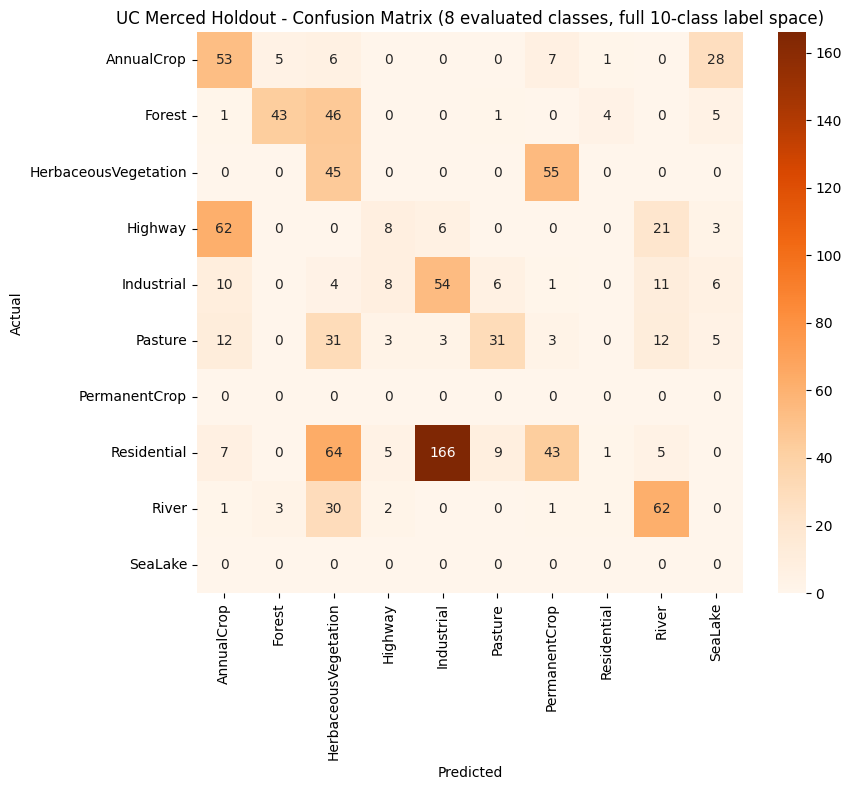

In [9]:
uc_ds = EuroSATDataset(uc_df, transform=uc_tf)
uc_ds.classes = train_ds.classes
uc_ds.class_to_idx = train_ds.class_to_idx  # critical -- must match the model's training label order, not UC Merced's own subset

uc_loader = DataLoader(uc_ds, batch_size=64, shuffle=False, num_workers=2)

model.eval()
uc_preds = []
uc_labels = []
with torch.no_grad():
    for imgs, labels in uc_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        uc_preds.extend(preds)
        uc_labels.extend(labels.numpy())

# evaluate against the FULL 10-class space, not just the 8 present in UC Merced
# this also reveals if the model wrongly predicts PermanentCrop/SeaLake on UC images, which is real info
print(classification_report(
    uc_labels, uc_preds,
    labels=list(range(10)),
    target_names=train_ds.classes,
    digits=3,
    zero_division=0
))

cm_uc = confusion_matrix(uc_labels, uc_preds, labels=list(range(10)))
plt.figure(figsize=(9,8))
sns.heatmap(cm_uc, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes, cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('UC Merced Holdout - Confusion Matrix (8 evaluated classes, full 10-class label space)')
plt.tight_layout()
plt.savefig('/kaggle/working/ucmerced_confusion_matrix.png')
plt.show()

In [ ]:
torch.save(model.state_dict(), '/kaggle/working/finetuned_resnet18.pt')